# AI Research Assistant

In [24]:
import os
from dotenv import load_dotenv
from tavily import TavilyClient
from langchain_tavily import TavilySearch, TavilyExtract
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from typing import Dict, TypedDict, List, Any 
from dataclasses import dataclass, field
from langgraph.graph import StateGraph, START, END

In [18]:
load_dotenv()
groq_api_key = os.environ.get("GROQ_API_KEY")
llm = ChatGroq(model="llama-3.3-70b-versatile",api_key=groq_api_key,temperature=0.6)

### Shared State

In [32]:
@dataclass
class SharedState:
    # the user query
    query: str
    # research findings updated by the research agent
    research: List[Dict[str, str]] = field(default_factory=list)
    # summary updated by the analyser
    analysis: str = ""
    # updated by the critic agent
    critique: Dict[str, Any] = field(default_factory=dict)
    # final report updated by the writer agent
    report: str = ""
    # keep track of number of revisions
    revision_count: int = 0
    # make the maximum number of revisions 2 so it caps the number of times this process occurs
    max_revisions: int = 2

In [20]:
class GraphState(TypedDict):
    pipeline_state: SharedState

In [ ]:
# class ResearcherAgent:

### Tools

In [38]:
tavily_api_key = os.getenv("TAVILY_API_KEY")
search_engine = TavilySearch(max_results=1) if tavily_api_key else None
extractor = TavilyExtract() if tavily_api_key else None

def web_search(query: str):
    if search_engine is None:
        raise RuntimeError("Search engine has not been initialized.")
    try:
        response = search_engine.invoke({"query": query})
        results = response.get("results", [])
        findings = []
        for result in results:
            findings.append({
                "title": result.get("title", "No Title"),
                "url": result.get("url", ""),
                "snippet": result.get("content", ""), 
                "full_text": "" })               
        return findings
    except Exception as e:
        print(str(e))
        return []

def web_extract(urls):
    if extractor is None:
        raise RuntimeError("Extractor has not been initialized.")
    try:
        extraction_results = extractor.invoke({"urls": urls})
        return extraction_results.get("results", [])
    except Exception as e:
        print(str(e))
        return []

def summariser(findings, query):
    if not findings:
        return "Nothing provided to summarise"
    content = ""
    for index, item in enumerate(findings):
        text = item.get("full_text") or item.get("snippet", "")
        content += f"SOURCE [{index+1}]\n (Title: {item['title']}\n URL: {item['url']}) \n{text}\n"

    if not llm:
        print("Not connected to LLM")
        
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "You are a research analyst. Summarize the provided information into a condensed and well-structured research brief answering the target user query. Only use the given context."),
        ("human", "User Target Query: {query}\n\nContext:\n{content}")
    ])
    
    try:
        chain = prompt_template | llm
        response = chain.invoke({"query": query, "content": content})
        return str(response.content)
    except Exception as e:
        return str(e)

In [ ]:
def researcher_node(state: GraphState):
    p_state = state["pipeline_state"]
    try:
        findings = web_search(query=p_state.query)
        target_urls = []
        for item in findings:
           if item.get("url"):
               target_urls.append(item["url"])
        
        if target_urls:
            contents = web_extract(urls=target_urls)
            extract_lookup = {}
            for item in contents:
                url_key = item["url"]
                raw_body = item.get("raw_content", "")
                extract_lookup[url_key] = raw_body

            for finding in findings:
                f_url = finding["url"]
                if f_url in extract_lookup:
                    finding["full_text"] = extract_lookup[f_url]
        p_state.research = findings
    except Exception as e:
        print(f"Research Agent Error: {str(e)}")
        return {"pipeline_state": p_state}
    return {"pipeline_state": p_state}


def analyzer_node(state: GraphState):
    p_state = state["pipeline_state"]
    try:
        summary = summariser(findings=p_state.research, query=p_state.query)
        p_state.analysis = summary
    except Exception as e:
        print(f"Analyzer Agent Error: {str(e)}")
    return {"pipeline_state": p_state}

In [29]:
workflow = StateGraph(GraphState)
workflow.add_node("Research Agent", researcher_node)
workflow.add_node("Analyser Agent", analyzer_node)

workflow.add_edge(START, "Research Agent") 
workflow.add_edge("Research Agent", "Analyser Agent")
workflow.add_edge("Analyser Agent", END)

graph = workflow.compile()

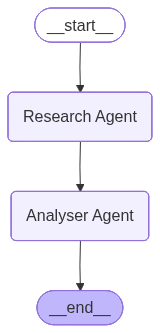

In [30]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))